# Chapter 111 — Reflection

> **Prerequisites:** ch108 (Transformations), ch068 (Reflection of Functions)
>
> **Outcomes:** Derive reflection matrices for x-axis, y-axis, and arbitrary lines; Compose reflections to produce rotations; Connect to symmetric functions and matrix symmetry


## Reflection Matrices

Reflection across:
- **x-axis** (y → -y): F_x = [[1, 0], [0, -1]]
- **y-axis** (x → -x): F_y = [[-1, 0], [0, 1]]
- **y = x** (swap): F_yx = [[0, 1], [1, 0]]
- **y = -x**: F_neg = [[0, -1], [-1, 0]]
- **Arbitrary line through origin at angle θ:**
  F(θ) = [[cos 2θ, sin 2θ], [sin 2θ, -cos 2θ]]

**Properties:**
- F² = I: reflecting twice returns to original
- det(F) = -1: reflection flips orientation (handedness)
- Two reflections = one rotation: F(θ₂)·F(θ₁) = R(2(θ₂-θ₁))

This fact — two reflections make a rotation — is fundamental to group theory and geometry.

F2∘F1 = R(90°)? True


C:\Users\user\AppData\Local\Temp\ipykernel_23400\1368940587.py:61: UserWarning: Glyph 8728 (\N{RING OPERATOR}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\user\AppData\Local\Temp\ipykernel_23400\1368940587.py:61: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\user\AppData\Local\Temp\ipykernel_23400\1368940587.py:61: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8728 (\N{RING OPERATOR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPytho

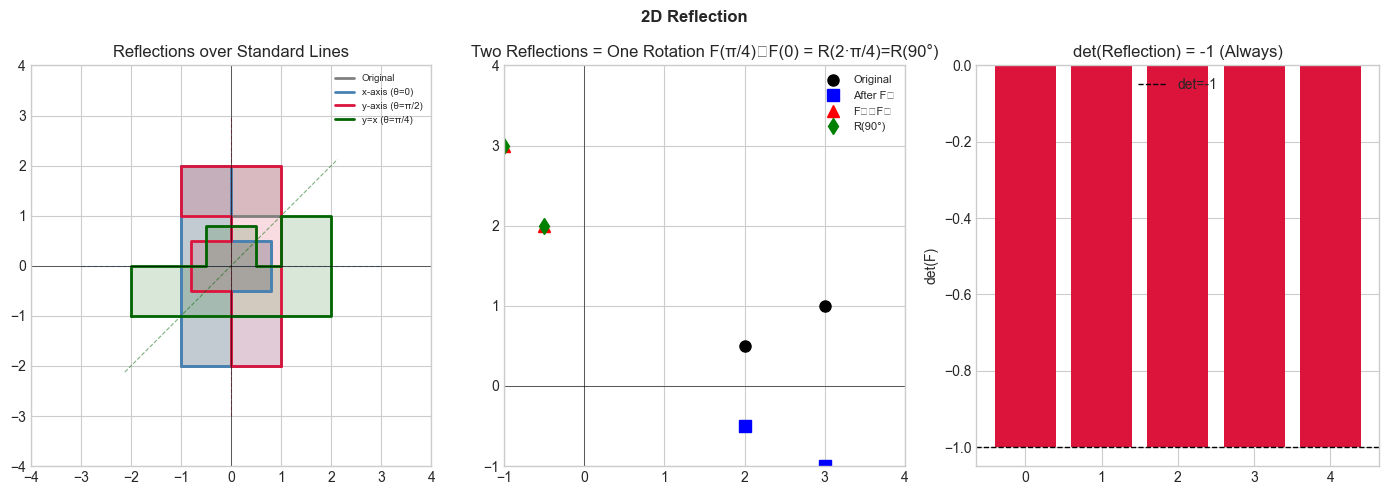

In [3]:
# --- Reflection matrices ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def reflect_over_line(theta):
    """Reflection over line through origin at angle theta."""
    c, s = np.cos(2*theta), np.sin(2*theta)
    return np.array([[c, s],[s, -c]])

def apply_mat(M, pts): return (M @ pts[:,:2].T).T

# F-shape polygon
F_poly = np.array([[0,0],[0,4],[2,4],[2,3],[1,3],[1,2.5],[1.8,2.5],[1.8,1.5],
                   [1,1.5],[1,0],[0,0]], dtype=float) - np.array([1,2])

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Standard reflections
ax = axes[0]
ax.fill(F_poly[:,0], F_poly[:,1], alpha=0.3, color='gray')
ax.plot(F_poly[:,0], F_poly[:,1], 'gray', lw=2, label='Original')
for (M, color, label) in [(reflect_over_line(0),'steelblue','x-axis (θ=0)'),
                           (reflect_over_line(np.pi/2),'crimson','y-axis (θ=π/2)'),
                           (reflect_over_line(np.pi/4),'darkgreen','y=x (θ=π/4)')]:
    ref = apply_mat(M, F_poly)
    ax.fill(ref[:,0], ref[:,1], alpha=0.15, color=color)
    ax.plot(ref[:,0], ref[:,1], color=color, lw=2, label=label)
    # Draw reflection line
    t = np.linspace(-3,3,2); theta_line = {'steelblue':0,'crimson':np.pi/2,'darkgreen':np.pi/4}
    th = [v for k,v in theta_line.items() if k==color][0]
    ax.plot(t*np.cos(th), t*np.sin(th), '--', color=color, lw=0.8, alpha=0.5)
ax.set_aspect('equal'); ax.legend(fontsize=7); ax.set_title('Reflections over Standard Lines')
ax.axhline(0, color='k', linewidth=0.4); ax.axvline(0, color='k', linewidth=0.4); ax.set_xlim(-4,4); ax.set_ylim(-4,4)

# Two reflections = one rotation
ax = axes[1]
M1 = reflect_over_line(0)         # reflect over x-axis
M2 = reflect_over_line(np.pi/4)   # reflect over y=x
R90 = np.array([[0,-1],[1,0]])     # rotation 90°

pt = np.array([[2,0.5],[3,1]])
p1 = apply_mat(M1, pt)
p2 = apply_mat(M2, p1)
p_R = apply_mat(R90, pt)

ax.plot(pt[:,0],pt[:,1],'ko',ms=8,label='Original'); ax.plot(p1[:,0],p1[:,1],'bs',ms=8,label='After F₁')
ax.plot(p2[:,0],p2[:,1],'r^',ms=8,label='F₂∘F₁'); ax.plot(p_R[:,0],p_R[:,1],'gd',ms=8,label='R(90°)')
print("F2∘F1 = R(90°)?", np.allclose(M2@M1, R90))
ax.set_aspect('equal'); ax.legend(fontsize=8); ax.set_title('Two Reflections = One Rotation F(π/4)∘F(0) = R(2·π/4)=R(90°)')
ax.axhline(0, color='k', linewidth=0.4); ax.axvline(0, color='k', linewidth=0.4); ax.set_xlim(-1,4); ax.set_ylim(-1,4)

# det = -1 for reflections
reflections = [reflect_over_line(t) for t in [0,np.pi/6,np.pi/4,np.pi/3,np.pi/2]]
dets = [np.linalg.det(M) for M in reflections]
axes[2].bar(range(len(dets)), dets, color=['crimson' if d < 0 else 'steelblue' for d in dets])
axes[2].axhline(-1, color='k', linewidth=1, linestyle='--', label='det=-1')
axes[2].set_title('det(Reflection) = -1 (Always)'); axes[2].set_ylabel('det(F)'); axes[2].legend()

plt.suptitle('2D Reflection', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Summary

- Reflect over line at angle θ: F(θ) = [[cos2θ, sin2θ],[sin2θ, -cos2θ]]
- F² = I; det(F) = -1 (flips orientation)
- Two reflections = one rotation: F(θ₂)·F(θ₁) = R(2(θ₂-θ₁))
- Symmetric matrices (Aᵀ=A) are the algebraic analog of geometric reflections (ch158)

**Forward:** ch113 composes all transforms; ch157 studies symmetric matrices.